## Imports

In [198]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.linalg as linalg

# Part 1

## Task 1

In [199]:


P = np.array([
    [0.9915, 0.005,  0.0025, 0.000, 0.001],
    [0.0000, 0.986,  0.0050, 0.004, 0.005],
    [0.0000, 0.000,  0.9920, 0.003, 0.005],
    [0.0000, 0.000,  0.0000, 0.991, 0.009],
    [0.0000, 0.000,  0.0000, 0.000, 1.000]
])


### Simulate 1 woman

In [200]:
states = np.array([1, 2, 3, 4, 5])

def simulate_one_woman(P):
    current_state = 1
    months = 0
    path = [current_state]

    while current_state != 5:
        probabilities = P[current_state - 1]

        current_state = np.random.choice(states, p=probabilities)

        months += 1
        path.append(current_state)

    return months, path


### Simulate 1000 women

#### set Parameters

In [201]:
n_women = 1000

lifetimes = []
paths = []

#### Start simulation

In [202]:
for _ in range(n_women):
    lifetime, path = simulate_one_woman(P)
    lifetimes.append(lifetime)
    paths.append(path)

lifetimes = np.array(lifetimes)


#### Show results

In [203]:
print("Mean lifetime:", np.mean(lifetimes))
print("Minimum lifetime:", np.min(lifetimes))
print("Maximum lifetime:", np.max(lifetimes))

Mean lifetime: 264.41
Minimum lifetime: 2
Maximum lifetime: 1346


#### Plot results

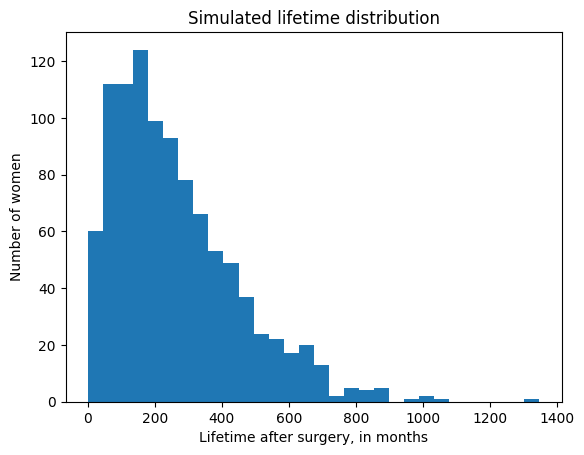

In [204]:
plt.hist(lifetimes, bins=30)
plt.xlabel("Lifetime after surgery, in months")
plt.ylabel("Number of women")
plt.title("Simulated lifetime distribution")
plt.show()

#### Women with local reccurence

state 2 is local recurrence
state 4 is local and distant recurrence

In [205]:
local_recurrence_count = 0

for path in paths:
    if 2 in path or 4 in path:
        local_recurrence_count += 1

proportion_local = local_recurrence_count / n_women

print("Proportion with local recurrence:", proportion_local)

Proportion with local recurrence: 0.677


## Task 2

### Analytical results

#### Setting parameters

In [206]:
t = 120
p0 = [1,0,0,0,0]

### defining $p_t$

In [207]:
def p_t(p0,t):
    res = np.linalg.matrix_power(P, t)
    return p0 @ res

### finding $P_{120}$

In [208]:

p_t(p0,120)


array([0.35902627, 0.15895604, 0.1660869 , 0.06774149, 0.2481893 ])

In [209]:
states_at_t = []
for path in paths:
    if len(path) <= t:
        states_at_t.append(5)
    else:
        states_at_t.append(path[t])

print(states_at_t)


[np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(4), np.int64(3), np.int64(2), np.int64(1), 5, np.int64(3), 5, np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(3), 5, np.int64(1), np.int64(1), 5, np.int64(2), 5, np.int64(4), np.int64(4), np.int64(2), np.int64(1), np.int64(1), np.int64(1), 5, 5, np.int64(1), np.int64(2), np.int64(2), 5, np.int64(1), 5, np.int64(1), 5, np.int64(1), np.int64(1), 5, np.int64(1), 5, np.int64(2), np.int64(1), np.int64(1), np.int64(4), np.int64(3), np.int64(2), np.int64(4), np.int64(2), 5, np.int64(3), 5, np.int64(1), np.int64(2), 5, np.int64(1), 5, np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), 5, np.int64(2), np.int64(1), np.int64(4), np.int64(2), np.int64(3), np.int64(1), np.int64(1), 5, np.int64(4), np.int64(4), np.int64(2), 5, 5, 5, np.int64(1), 5, np.int64(1), 5, np.int64(1), np.int64(3), np.int64(1), np.int64(2), 5, np.int64(2), 5, 5, np.int64(3), np.int64(4), np.int64(2)

### Comparison of simulation and theory

In [210]:
states_at_t = np.array(states_at_t)

observed_counts = np.array([np.sum(states_at_t == 1),np.sum(states_at_t == 2),np.sum(states_at_t == 3),np.sum(states_at_t == 4),np.sum(states_at_t == 5)])

p0 = np.array([1, 0, 0, 0, 0])
theoretical_distribution = p0 @ np.linalg.matrix_power(P, t)

expected_counts = theoretical_distribution * n_women

chi2_stat, p_value = stats.chisquare(f_obs=observed_counts,f_exp=expected_counts)

print("Observed counts: ", observed_counts)
print("Expected counts: ", expected_counts)
print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

Observed counts:  [352 179 152  65 252]
Expected counts:  [359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]
Chi-square statistic: 4.029257775561566
p-value: 0.40206072128077486


### Task 3

#### Defining parameters

In [211]:
P_s = P[:4, :4]
p_s = P[:4, 4]
pi = np.array([1, 0, 0, 0])


#### Defining function

In [212]:
def Discrete_phase(t):
    return pi @ np.linalg.matrix_power(P_s, t) @ p_s

print("P(T=120)",Discrete_phase(t=120))

def lifetime_prob(t): #offset by one because you die on transition t, so you have survied until t-1
    return pi @ np.linalg.matrix_power(P_s, t - 1) @ p_s


P(T=120) 0.002593914399220477


#### Does my simulation follow this distribution?

In [213]:
bins = np.array([0, 50, 100, 150, 200, 250, 300, 400, 600, np.inf])

observed_counts, _ = np.histogram(lifetimes, bins=bins)

bin_probs = []

for i in range(len(bins) - 1):
    lower = int(bins[i]) + 1

    if np.isinf(bins[i + 1]):
        # Probability T > bins[i]
        prob = pi @ np.linalg.matrix_power(P_s, int(bins[i])) @ np.ones(4)
    else:
        upper = int(bins[i + 1])
        prob = sum(lifetime_prob(t) for t in range(lower, upper + 1))

    bin_probs.append(prob)

bin_probs = np.array(bin_probs)

expected_counts = bin_probs * len(lifetimes)

print("Observed:", observed_counts)
print("Expected:", expected_counts)

print("Observed sum:", observed_counts.sum())
print("Expected sum:", expected_counts.sum())
print("Bin probability sum:", bin_probs.sum())



Observed: [ 70 124 120 129 115  89 146 141  66]
Expected: [ 79.47467179 117.33273873 129.28291046 125.06676628 112.18377797
  95.72601894 142.00013366 138.92281264  60.01016954]
Observed sum: 1000
Expected sum: 1000.0000000000023
Bin probability sum: 1.0000000000000022


In [214]:
expected_counts = expected_counts * observed_counts.sum() / expected_counts.sum() # Have to do this or the probability doesnt add up to 1



chi2_stat, p_value = stats.chisquare(f_obs=observed_counts,f_exp=expected_counts)

print(observed_counts)
print(expected_counts)

chi2_stat, p_value = stats.chisquare(f_obs=observed_counts,f_exp=expected_counts)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

[ 70 124 120 129 115  89 146 141  66]
[ 79.47467179 117.33273873 129.28291046 125.06676628 112.18377797
  95.72601894 142.00013366 138.92281264  60.01016954]
Chi-square statistic: 3.583512653584731
p-value: 0.8926124737159866


### Task 4

#### Set paramets

In [215]:
t_min = 12

#### Make rejection function

In [216]:
def Rejection_simulation(t_min, amount):
    lifetimes = []
    paths = []

    while len(lifetimes) < amount:
        lifetime, path = simulate_one_woman(P)

        # Did she survive the first t_min months?
        survived = lifetime > t_min

        # States during the first t_min months
        path_first_t_min = path[:t_min + 1]

        # Did cancer reappear locally or distantly within first t_min months?
        recurrence = (2 in path_first_t_min or 3 in path_first_t_min or 4 in path_first_t_min)

        if survived and recurrence:
            lifetimes.append(lifetime)
            paths.append(path)

    lifetimes = np.array(lifetimes)

    return lifetimes, paths

    

#### generate simulations

In [217]:
accepted_lifetimes, accepted_paths = Rejection_simulation(t_min, n_women)

print("mean lifetime of women who survives atleast 12 months but cancer does reappear:", np.mean(accepted_lifetimes))

mean lifetime of women who survives atleast 12 months but cancer does reappear: 176.969


### Task 5

In [218]:
one = np.ones(4)
mean_lifetime_theoretical = pi @ np.linalg.inv(np.eye(4) - P_s) @ one

X_values = []  # fractions dying within 350 months
Y_values = []  # mean lifetimes

n_repetitions = 100
n_women = 200

for _ in range(n_repetitions):
    lifetimes_200 = []

    for _ in range(n_women):
        lifetime, path = simulate_one_woman(P)
        lifetimes_200.append(lifetime)

    lifetimes_200 = np.array(lifetimes_200)

    X = np.mean(lifetimes_200 <= 350)
    Y = np.mean(lifetimes_200)

    X_values.append(X)
    Y_values.append(Y)

X_values = np.array(X_values)
Y_values = np.array(Y_values)

crude_estimate = np.mean(X_values)
crude_variance = np.var(X_values, ddof=1)

b = np.cov(X_values, Y_values, ddof=1)[0, 1] / np.var(Y_values, ddof=1)

X_cv_values = X_values - b * (Y_values - mean_lifetime_theoretical)

cv_estimate = np.mean(X_cv_values)
cv_variance = np.var(X_cv_values, ddof=1)

print("Theoretical mean lifetime:", mean_lifetime_theoretical)

print("Crude estimate:", crude_estimate)
print("Control variate estimate:", cv_estimate)

print("Crude variance:", crude_variance)
print("Control variate variance:", cv_variance)

print("Variance reduction factor:", crude_variance / cv_variance)

Theoretical mean lifetime: 262.37161531279304
Crude estimate: 0.7417999999999999
Control variate estimate: 0.7398883413508973
Crude variance: 0.0008921818181818191
Control variate variance: 0.0002874555910292058
Variance reduction factor: 3.103720525968731


### Task 6

## Part 2

#### Task 7

#### Setting parameters

In [219]:
Q = np.array([
    [-0.0085, 0.005,  0.0025, 0.000, 0.001],
    [ 0.0000,-0.014,  0.0050, 0.004, 0.005],
    [ 0.0000, 0.000, -0.0080, 0.003, 0.005],
    [ 0.0000, 0.000,  0.0000,-0.009, 0.009],
    [ 0.0000, 0.000,  0.0000, 0.000, 0.000]
])
n_women = 1000

#### Simulate a woman

In [220]:
def simulate_one_woman_ctmc(Q):
    current_state = 1
    time = 0.0
    path = [(time, current_state)]

    while current_state != 5:
        row = Q[current_state - 1]

        rate = -row[current_state - 1]

        waiting_time = np.random.exponential(scale= 1/rate)
        time += waiting_time

        jump_rates = row.copy()
        jump_rates[current_state - 1] = 0

        probabilities = jump_rates / rate

        next_state = np.random.choice(np.array([1, 2, 3, 4, 5]),p=probabilities)

        current_state = next_state
        path.append((time, current_state))

    return time, path

In [221]:
lifetimes_ctmc = []
paths_ctmc = []

for _ in range(n_women):
    lifetime, path = simulate_one_woman_ctmc(Q)
    lifetimes_ctmc.append(lifetime)
    paths_ctmc.append(path)

lifetimes_ctmc = np.array(lifetimes_ctmc)

print(paths_ctmc)



[[(0.0, 1), (33.265851543523574, np.int64(3)), (305.0443864373062, np.int64(5))], [(0.0, 1), (140.40962266606894, np.int64(3)), (313.0750221114946, np.int64(5))], [(0.0, 1), (1.0904205357006913, np.int64(3)), (200.16073261733203, np.int64(4)), (249.3944995180471, np.int64(5))], [(0.0, 1), (222.60019655633317, np.int64(2)), (337.15117767856594, np.int64(3)), (388.6227258572528, np.int64(5))], [(0.0, 1), (22.26556294972429, np.int64(2)), (119.99289115143551, np.int64(4)), (169.36745597239627, np.int64(5))], [(0.0, 1), (319.18182735907965, np.int64(2)), (415.3163874039444, np.int64(5))], [(0.0, 1), (125.87280870295534, np.int64(2)), (339.0970692942681, np.int64(3)), (692.4972476927812, np.int64(4)), (862.9451912604875, np.int64(5))], [(0.0, 1), (154.33150140803792, np.int64(2)), (233.46134606856756, np.int64(5))], [(0.0, 1), (145.41825535069856, np.int64(5))], [(0.0, 1), (105.99941235308661, np.int64(2)), (254.63728178863, np.int64(5))], [(0.0, 1), (126.63074625721606, np.int64(2)), (258.

#### Histogram

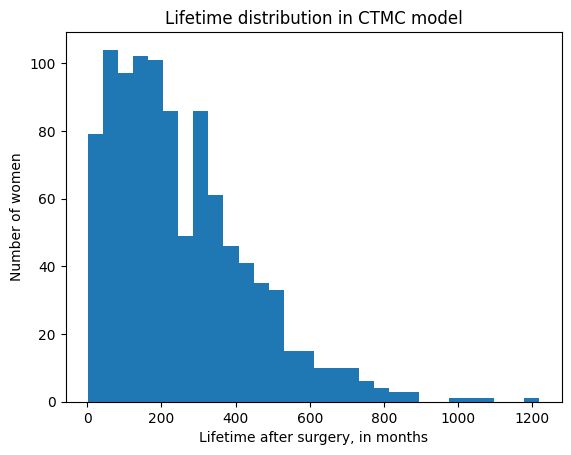

In [222]:
plt.hist(lifetimes_ctmc, bins=30)
plt.xlabel("Lifetime after surgery, in months")
plt.ylabel("Number of women")
plt.title("Lifetime distribution in CTMC model")
plt.show()

#### Mean confidence interval

In [223]:
mean_lifetime = np.mean(lifetimes_ctmc)
std_lifetime = np.std(lifetimes_ctmc, ddof=1)

n = len(lifetimes_ctmc)

mean_se = std_lifetime / np.sqrt(n)

mean_ci = (mean_lifetime - 1.96 * mean_se,mean_lifetime + 1.96 * mean_se) #1.96 is the critical value for 95% Ci

print("Mean lifetime:", mean_lifetime)
print("95% CI for mean:", mean_ci)

Mean lifetime: 254.08079652026964
95% CI for mean: (np.float64(242.62117274717056), np.float64(265.5404202933687))


#### std and confidence interval

In [224]:
alpha = 0.05
df = n - 1

sample_variance = np.var(lifetimes_ctmc, ddof=1)

var_ci_lower = df * sample_variance / stats.chi2.ppf(1 - alpha / 2, df)
var_ci_upper = df * sample_variance / stats.chi2.ppf(alpha / 2, df)

std_ci = (np.sqrt(var_ci_lower),np.sqrt(var_ci_upper))

print("Standard deviation:", std_lifetime)
print("95% CI for standard deviation:", std_ci)

Standard deviation: 184.89036863064132
95% CI for standard deviation: (np.float64(177.12725638245797), np.float64(193.37043146723005))


#### cancer after 30.5 months

In [225]:
t_check = 30.5

distant_count = 0

for path in paths_ctmc:
    had_distant = False

    for time, state in path:
        if time <= t_check and (state == 3 or state == 4):
            had_distant = True

    if had_distant:
        distant_count += 1

proportion_distant = distant_count / n_women

print("Proportion with distant recurrence after 30.5 months:", proportion_distant)

Proportion with distant recurrence after 30.5 months: 0.075


### Task 8

#### Defining parameters

In [226]:
Q_s = Q[:4,:4]
p_0 = [1,0,0,0]


In [227]:


#def CTMC_distribution(t):
#    return 1 - p_0 @ linalg.expm(Q_s*t) @ one


def CTMC_distribution(t):
    t = np.asarray(t)

    return np.array([
        1 - p_0 @ linalg.expm(Q_s * ti) @ one
        for ti in t
    ])


In [228]:
ks_stat, p_value = stats.kstest(lifetimes_ctmc, CTMC_distribution)

print("K-S statistic:", ks_stat)
print("p-value:", p_value)

K-S statistic: 0.03458484403353912
p-value: 0.17853853837941125


#### Task 9

#### Defining parameters

In [268]:
Q_treatment = np.array([
    [-0.00475, 0.0025, 0.00125, 0.000, 0.001],
    [ 0.00000,-0.0070, 0.00000, 0.002, 0.005],
    [ 0.00000, 0.0000,-0.00800, 0.003, 0.005],
    [ 0.00000, 0.0000, 0.00000,-0.009, 0.009],
    [ 0.00000, 0.0000, 0.00000, 0.000, 0.000]
])

In [269]:
def death(t, paths):
    death_count = 0

    for path in paths:
        is_dead = False

        for time, state in path:
            if time < t and state == 5:
                is_dead = True
                break

        if is_dead:
            death_count += 1

    return death_count


def kaplan_meier(t, paths):
    N = len(paths)
    return (N - death(t, paths)) / N





In [270]:



lifetimes_treatment = []
paths_treatment = []

for _ in range(n_women):
    lifetime, path = simulate_one_woman_ctmc(Q_treatment)
    lifetimes_treatment.append(lifetime)
    paths_treatment.append(path)

lifetimes_treatment = np.array(lifetimes_treatment)

death(230, paths_treatment)

409

In [271]:
max_time = max(np.max(lifetimes_ctmc), np.max(lifetimes_treatment))
times = np.linspace(0, max_time, 500)

S_no_treatment = np.array([kaplan_meier(t, paths_ctmc)for t in times])

S_treatment = np.array([kaplan_meier(t, paths_treatment)for t in times])

#### Plot

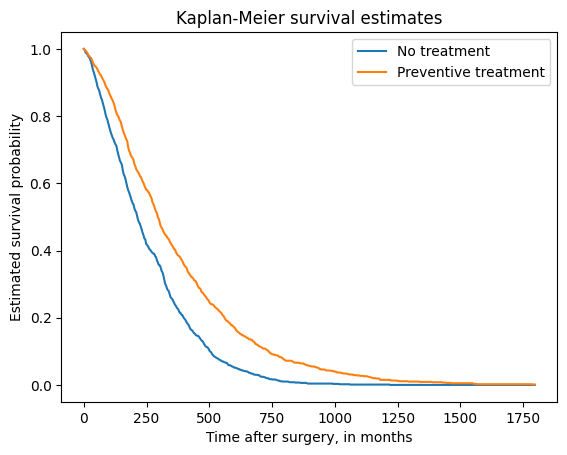

In [233]:
plt.plot(times, S_no_treatment, label="No treatment")
plt.plot(times, S_treatment, label="Preventive treatment")

plt.xlabel("Time after surgery, in months")
plt.ylabel("Estimated survival probability")
plt.title("Kaplan-Meier survival estimates")
plt.legend()
plt.show()

### Task 10

#### Log rank test

In [265]:
def log_rank_test(lifetimes_1, lifetimes_2):

    lifetimes_1 = np.array(lifetimes_1)
    lifetimes_2 = np.array(lifetimes_2)

    # All unique death times
    event_times = np.sort(np.unique(np.concatenate([lifetimes_1, lifetimes_2])))

    O1_total = 0
    E1_total = 0
    V1_total = 0

    n1 = len(lifetimes_1)
    n2 = len(lifetimes_2)

    for t in event_times:
        # Number at risk just before time t
        Y1 = np.sum(lifetimes_1 >= t)
        Y2 = np.sum(lifetimes_2 >= t)
        Y = Y1 + Y2

        # Number of deaths at time t
        d1 = np.sum(lifetimes_1 == t)
        d2 = np.sum(lifetimes_2 == t)
        d = d1 + d2

        if Y <= 1:
            continue

        # Observed deaths in group 1
        O1_total += d1

        # Expected deaths in group 1 under equal survival functions
        E1_total += d * (Y1 / Y)

        # Variance contribution
        V1_total += (
            (Y1 * Y2 * d * (Y - d)) /
            (Y**2 * (Y - 1))
        )

    test_statistic = (O1_total - E1_total)**2 / V1_total

    # More numerically stable than 1 - stats.chi2.cdf(...)
    p_value = stats.chi2.sf(test_statistic, df=1)

    return test_statistic, p_value

In [266]:
test_statistic, p_value = log_rank_test(lifetimes_ctmc, lifetimes_treatment)

print("Log-rank test statistic:", test_statistic)
print("p-value:", p_value)


Log-rank test statistic: 109.72666587259516
p-value: 1.1247852638420437e-25


## Part 3

### Defining parameters

In [234]:
def create_observation(amount, Q):
    res_array = []
    timesteps = 48
    for i in range(amount):
        time_series = []
        time, path = simulate_one_woman_ctmc(Q)

        prev_stage = 1
        time_series.append(1)
        count = 1
        for time, stage in path:
            while (int(time/(timesteps*count))) > 0:
                count += 1
                time_series.append(prev_stage)
            
            prev_stage = stage
            if (prev_stage == 5):
                time_series.append(prev_stage)

        res_array.append(time_series)

    return res_array


In [235]:
observations = create_observation(1000,Q)

In [236]:
def Generate_Q0(observations, n_states=5, interval_length=48):
    N = np.zeros((n_states, n_states))
    S = np.zeros(n_states)

    for timeseries in observations:

        for k in range(len(timeseries) - 1):
            prev_state = timeseries[k]
            next_state = timeseries[k + 1]


            S[prev_state - 1] += interval_length

            # If the observed state changed, count one transition.
            if next_state != prev_state:
                N[prev_state - 1, next_state - 1] += 1

    Q = np.zeros((n_states, n_states))

    for i in range(n_states):
        if S[i] > 0:
            for j in range(n_states):
                if i != j:
                    Q[i, j] = N[i, j] / S[i]

            Q[i, i] = -np.sum(Q[i, :])


    Q[-1, :] = 0

    return Q,N,S

In [237]:
Q0,_,_ = Generate_Q0(observations)

In [238]:
print(Q0)

[[-0.0071543   0.00297619  0.00211767  0.00037918  0.00168126]
 [ 0.         -0.01022013  0.00321836  0.0025796   0.00442217]
 [ 0.          0.         -0.00665358  0.00176078  0.00489279]
 [ 0.          0.          0.         -0.00665782  0.00665782]
 [ 0.          0.          0.          0.          0.        ]]


In [ ]:
def simulate_interval(Q_current, start_state, interval_length=48, n_states=5):

    N = np.zeros((n_states, n_states))
    S = np.zeros(n_states)

    current_state = start_state
    time = 0.0

    while time < interval_length:

        #stay dead for the rest of the interval
        if current_state == 5:
            S[current_state - 1] += interval_length - time
            break

        row = Q_current[current_state - 1]
        rate = -row[current_state - 1]

        # if rate is zero no jumps can happen
        if rate <= 0:
            S[current_state - 1] += interval_length - time
            break

        waiting_time = np.random.exponential(scale=1 / rate)

        # If the next jump happens after 48 months, no jump occurs in this interval
        if time + waiting_time >= interval_length:
            S[current_state - 1] += interval_length - time
            break

        # Otherwise, record time spent in current state
        S[current_state - 1] += waiting_time
        time += waiting_time

        # Choose next state
        jump_rates = row.copy()
        jump_rates[current_state - 1] = 0

        probabilities = jump_rates / rate

        next_state = np.random.choice(
            np.array([1, 2, 3, 4, 5]),
            p=probabilities
        )

        N[current_state - 1, next_state - 1] += 1
        current_state = next_state

    return current_state, N, S

In [240]:
def simulate_interval_conditioned(Q_current, start_state, end_state, interval_length=48, max_attempts=10000):
    """
    Simulate a 48-month interval from start_state.
    Only accept the interval if the final state equals end_state.
    """
    for _ in range(max_attempts):
        final_state, N, S = simulate_interval(
            Q_current,
            start_state,
            interval_length
        )

        if final_state == end_state:
            return N, S

    raise RuntimeError(
        f"Could not simulate interval from {start_state} to {end_state} "
        f"within {max_attempts} attempts."
    )

In [241]:
def Generate_Q_from_current(observations, Q_current, n_states=5, interval_length=48):
    """
    Uses Q_current to simulate possible complete paths between observations.
    Then estimates a new Q using q_ij = N_ij / S_i.
    """
    N_total = np.zeros((n_states, n_states))
    S_total = np.zeros(n_states)

    for timeseries in observations:
        for k in range(len(timeseries) - 1):
            start_state = timeseries[k]
            end_state = timeseries[k + 1]

            N_interval, S_interval = simulate_interval_conditioned(
                Q_current,
                start_state,
                end_state,
                interval_length
            )

            N_total += N_interval
            S_total += S_interval

    Q_new = np.zeros((n_states, n_states))

    for i in range(n_states):
        # State 5 is death, so it is absorbing
        if i == 4:
            continue

        if S_total[i] > 0:
            for j in range(n_states):
                if i != j:
                    Q_new[i, j] = N_total[i, j] / S_total[i]

            Q_new[i, i] = -np.sum(Q_new[i, :])

        else:
            # If no time was observed in this state, keep the old row
            Q_new[i, :] = Q_current[i, :]

    Q_new[4, :] = 0

    return Q_new, N_total, S_total

In [242]:
def find_Q(Q0, observations, max_iter=10, tol=10**(-3)):
    Q_prev = Q0.copy()

    Q_list = [Q_prev]
    N_list = []
    S_list = []

    for iteration in range(max_iter):
        Q_new, N, S = Generate_Q_from_current(observations, Q_prev)

        difference = np.max(np.abs(Q_new - Q_prev))

        print("Iteration:", iteration + 1)
        print("Difference:", difference)
        print(Q_new)

        Q_list.append(Q_new)
        N_list.append(N)
        S_list.append(S)

        if difference < tol:
            break

        Q_prev = Q_new.copy()

    return Q_new, N_list, S_list, Q_list

In [244]:
observations = create_observation(1000, Q)


Q0,_,_ = Generate_Q0(observations)

Q_est, N_list, S_list, Q_list = find_Q(Q0, observations)

print("Estimated Q:")
print(Q_est)

print("True Q:")
print(Q)

Iteration: 1
Difference: 0.002059509875521488
[[-0.00820429  0.00410215  0.00237104  0.00041021  0.00132089]
 [ 0.         -0.0126372   0.00419555  0.00331095  0.0051307 ]
 [ 0.          0.         -0.00792822  0.00317129  0.00475693]
 [ 0.          0.          0.         -0.00841349  0.00841349]
 [ 0.          0.          0.          0.          0.        ]]
Iteration: 2
Difference: 0.0004081657837994371
[[-0.00833768  0.004469    0.00233455  0.00033351  0.00120063]
 [ 0.         -0.01304536  0.00445392  0.00352906  0.00506238]
 [ 0.          0.         -0.00811611  0.003278    0.00483812]
 [ 0.          0.          0.         -0.00851881  0.00851881]
 [ 0.          0.          0.          0.          0.        ]]
Estimated Q:
[[-0.00833768  0.004469    0.00233455  0.00033351  0.00120063]
 [ 0.         -0.01304536  0.00445392  0.00352906  0.00506238]
 [ 0.          0.         -0.00811611  0.003278    0.00483812]
 [ 0.          0.          0.         -0.00851881  0.00851881]
 [ 0.     